![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

Tasks:
- Import, investigate and pre-process the "penguins.csv" dataset.
- Perform a cluster analysis based on a reasonable number of clusters and collect the average values for the clusters. The output should be a DataFrame named `stat_penguins` with one row per cluster that shows the mean of the original variables (or columns in `"penguins.csv"`) by cluster. `stat_penguins` should not include any non-numeric columns.


In [38]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Loading and examining the dataset
penguins = pd.read_csv("penguins.csv")
penguins.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


### Check for nulls

In [39]:
penguins.isna().sum()

culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

### Drop non-numeric column

In [41]:
penguins = penguins.drop("sex",axis=1)

### Scale the data

In [42]:
scaler = StandardScaler()
scaler.fit(penguins)
StandardScaler(copy=True, with_mean=True, with_std=True) 
samples_scaled = scaler.transform(penguins)


### Test KMeans models with different no. of clusters and store its corresponding inertia

In [48]:
results = {}
for n_clusters in range(3,11):
    model = KMeans(n_clusters=n_clusters)
    model.fit(penguins)
    inertia = model.inertia_
    print(f"Inertia at n_clusters = {n_clusters}: {inertia}")
    results[n_clusters] = inertia

    

Inertia at n_clusters = 3: 28514731.64201217
Inertia at n_clusters = 4: 15925656.423800768
Inertia at n_clusters = 5: 10891071.52997901
Inertia at n_clusters = 6: 8238213.175886738
Inertia at n_clusters = 7: 5963084.632192425
Inertia at n_clusters = 8: 4996937.778848822
Inertia at n_clusters = 9: 4008434.7821027962
Inertia at n_clusters = 10: 3162779.289621624


### Plot the inertia vs no. of clusters

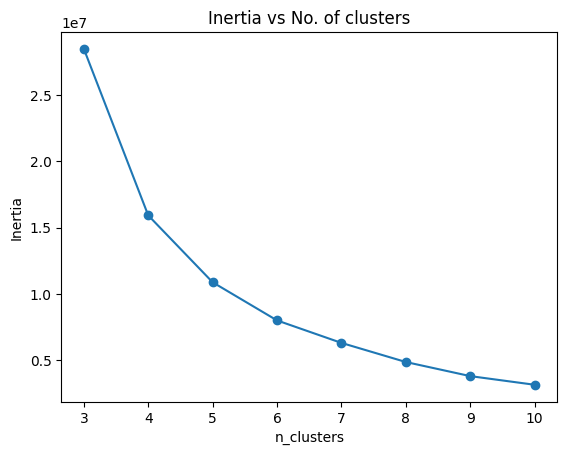

In [44]:
x = list(results.keys())
y = list(results.values())

plt.plot(x,y,marker="o")
plt.xlabel("n_clusters")
plt.ylabel("Inertia")
plt.title("Inertia vs No. of clusters")
plt.show()

#### Since the inertia started to decrease slowly at n_clusters=5, we would be using that for the model

### Create the model and fit the data

In [45]:
kmeans = KMeans(n_clusters=5)
labels = kmeans.fit_predict(penguins)
penguins["cluster"] = labels

### Get the mean of each feature per cluster

In [46]:
stat_penguins = penguins.groupby("cluster").mean()

### Display the resulting dataframe

In [47]:
stat_penguins

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
cluster,,,,
0,45.661765,15.575000,210.500000,4770.955882
1,43.862500,18.152778,198.680556,4119.097222
2,39.120833,17.366667,187.520833,3159.375000
3,49.739623,15.749057,221.867925,5563.207547
4,42.174725,18.246154,190.604396,3615.934066


### Perform PCA to visualize the clusters

c:\Users\Kendot\Documents\Code\Data Camp Projects\DataCamp-Projects\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


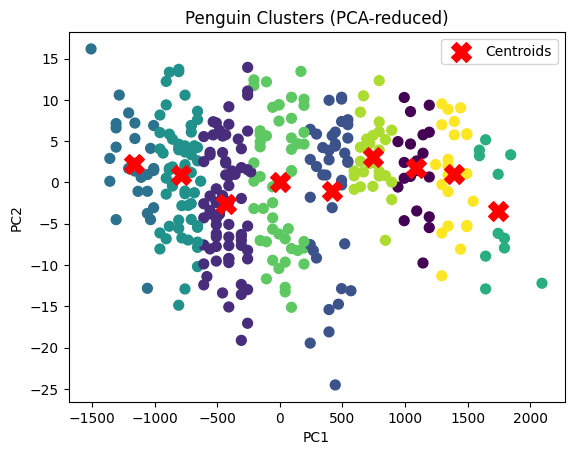

In [35]:
X = penguins.drop("cluster",axis=1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

centers_pca = pca.transform(kmeans.cluster_centers_)

# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", s=50)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
            c="red", marker="X", s=200, label="Centroids")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Penguin Clusters (PCA-reduced)")
plt.legend()
plt.show()